# ARIMA


## Import libraries

In [22]:
import warnings
import ccxt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

In [23]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

In [24]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
TIMEFRAME = "1h"
TRAIN_TEST_SPLIT_RATIO = 0.7
WINDOW_SIZE = 240
AR_ORDER_CANDIDATES = range(0, 3)
MA_ORDER_CANDIDATES = range(0, 3)
DIFFERENCING_ORDER = 1  # fixed d=1; compare p,q by AIC only at the same d
OUTPUT_VALUE = "log_return_close"
CLASSIFICATION_TARGET = "bin_return_d2d_close"  # same name as XGBoost / Random Forest
RETURN_SCALE = 100.0  # numerical conditioning; forecasts are divided by this factor
START_CASH = 1000.0
BET_PAYOUT = 10.0

## Fetching data

In [25]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        limit = 1000 if end_date - start_date >= TIMEFRAME_DICT[timeframe] * 1000 else (end_date - start_date) // (TIMEFRAME_DICT[timeframe])
        if limit <= 0:
            break
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=limit,
        )
        
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    # data = data.where(data["Date"] <= END_DATE + 4 * TIMEFRAME_DICT["1h"]).dropna()
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [26]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035


### Verifying continuous of data

In [27]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)
if len(missing) or data.index.has_duplicates or not data.index.is_monotonic_increasing:
    raise ValueError("ARIMA requires ordered, unique, continuous candles.")

0 DatetimeIndex([], dtype='datetime64[ms]', freq='h')


## Processing data

In [28]:
data['log_return_close'] = np.log(data['Close'] / data['Close'].shift(1))
data['return_close'] = data['Close'] / data['Close'].shift(1) - 1
data['bin_return_close'] = (data['log_return_close'] > 0).astype(int)
data['bin_return_d2d_close'] = (data['log_return_close'] > data['log_return_close'].shift(1)).astype(int)

In [29]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,,,,,
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031,0.000203,0.000203,1,0
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337,0.000786,0.000786,1,1
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032,0.002556,0.002560,1,1
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035,-0.000580,-0.000580,0,0
2023-11-04 01:00:00,34696.66,34786.68,34632.47,34768.15,724.86868,0.002059,0.002061,1,1


## Spliting data

In [30]:
series = data[OUTPUT_VALUE].copy()
# Match XGBoost / Random Forest: split before lag generation, then remove
# the first WINDOW_SIZE targets of the test block used there as history.
train_series, remaining_series = train_test_split(
    series, test_size=1-TRAIN_TEST_SPLIT_RATIO, shuffle=False)
val_series, test_block = train_test_split(remaining_series, test_size=0.5, shuffle=False)
if min(len(train_series), len(val_series), len(test_block)) <= WINDOW_SIZE:
    raise ValueError("Every split must contain more than WINDOW_SIZE observations.")
test_series = test_block.iloc[WINDOW_SIZE:].copy()
history_seed = series.loc[series.index < test_series.index[0]].copy()
test_returns = data.loc[test_series.index, "return_close"].copy()
# True previous observed return, never the previous forecast.
previous_returns = series.shift(1).loc[test_series.index]
y_test = data.loc[test_series.index, CLASSIFICATION_TARGET].astype(int)
assert np.array_equal(y_test.to_numpy(), (test_series > previous_returns).astype(int).to_numpy())

In [31]:
split_summary = pd.DataFrame(
    {"raw_samples": [len(train_series), len(val_series), len(test_block)],
     "targets_after_240_lags": [len(train_series)-WINDOW_SIZE,
                                len(val_series)-WINDOW_SIZE, len(test_series)]},
    index=["train", "validation", "test"],
)
split_summary

,raw_samples,targets_after_240_lags
train,14766,14526
validation,3164,2924
test,3165,2925


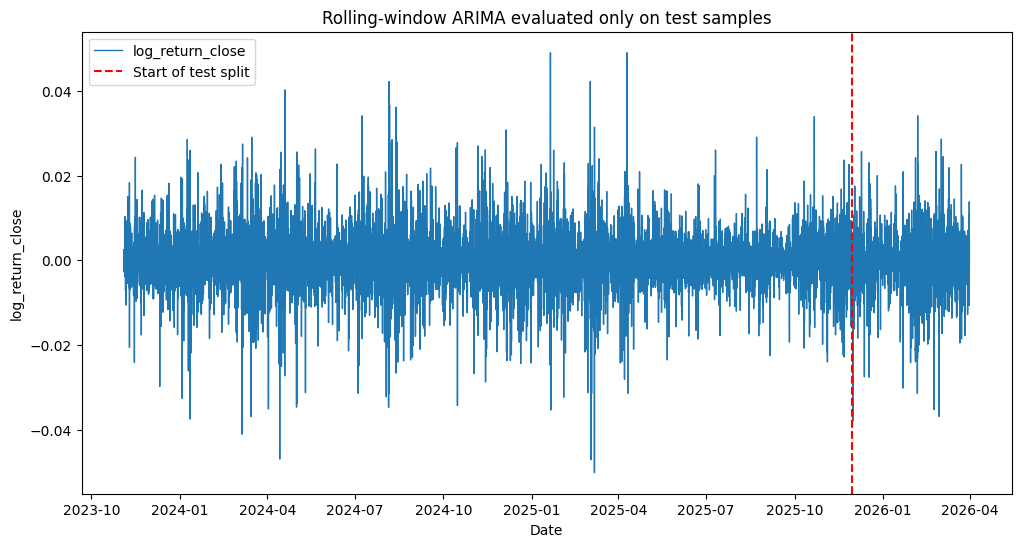

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(series.index, series, label=OUTPUT_VALUE, linewidth=1)
plt.axvline(test_series.index[0], color="red", linestyle="--", label="Start of test split")
plt.title("Rolling-window ARIMA evaluated only on test samples")
plt.xlabel("Date")
plt.ylabel("log_return_close")
plt.legend()
plt.show()

In [33]:
def fit_arima(window_series, ar_order, ma_order):
    # Fit ARIMA(p,1,q) on log returns, not on prices. Differencing is internal.
    # forecast() returns log-return levels, so do not cumulatively sum forecasts.
    # Log returns may already be stationary; d=1 is an experimental comparison
    # with the separate ARMA (d=0) notebook, not an assumed improvement.
    values = np.asarray(window_series, dtype=float) * RETURN_SCALE
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        result = ARIMA(values, order=(ar_order, DIFFERENCING_ORDER, ma_order), trend="n",
                       enforce_stationarity=True, enforce_invertibility=True).fit()
    converged = bool(result.mle_retvals.get("converged", True))
    if not converged or any(issubclass(w.category, ConvergenceWarning) for w in caught):
        raise ValueError("ARIMA optimization did not converge.")
    return result


def select_best_arima_model(window_series, ar_candidates, ma_candidates):
    best_result, rejected = None, 0
    # Include ARIMA(0,1,0): no-drift random walk of log returns.
    # Its one-step forecast equals the last log return; strict > maps ties to 0.
    for ar_order in ar_candidates:
        for ma_order in ma_candidates:
            try:
                candidate = fit_arima(window_series, ar_order, ma_order)
                prediction = float(np.asarray(candidate.forecast(steps=1)).ravel()[0]) / RETURN_SCALE
                if not np.isfinite(candidate.aic) or not np.isfinite(prediction):
                    raise ValueError("Non-finite AIC or forecast.")
                if best_result is None or candidate.aic < best_result["AIC"]:
                    best_result = {"p": ar_order, "d": DIFFERENCING_ORDER, "q": ma_order, "AIC": float(candidate.aic),
                                   "prediction": prediction}
            except (ValueError, np.linalg.LinAlgError):
                rejected += 1
    if best_result is None:
        raise RuntimeError("No converged ARIMA candidate for this window; inspect data / orders.")
    best_result["rejected_candidates"] = rejected
    return best_result


def forecast_metrics(y_true, y_pred):
    return pd.Series({"MAE": mean_absolute_error(y_true, y_pred),
                      "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))})


def rolling_window_forecast(history_series, forecast_index, window_size,
                            ar_candidates, ma_candidates, actual_values, label="test"):
    history = history_series.copy()
    predictions, diagnostics = [], []
    if not history.index.is_unique or not history.index.is_monotonic_increasing:
        raise ValueError("History must be ordered and unique.")
    if not forecast_index.is_unique or not forecast_index.is_monotonic_increasing:
        raise ValueError("Forecast timestamps must be ordered and unique.")
    if not actual_values.index.is_unique:
        raise ValueError("Actual values must have unique timestamps.")
    if len(history) < window_size or history.index[-1] >= forecast_index[0]:
        raise ValueError("Need 240 past observations strictly before the first forecast.")
    for step, timestamp in enumerate(forecast_index, start=1):
        window = history.iloc[-window_size:]
        assert len(window) == window_size and window.index[-1] < timestamp
        if timestamp - window.index[-1] != pd.Timedelta(milliseconds=TIMEFRAME_DICT[TIMEFRAME]):
            raise ValueError("Forecast must follow the last observed candle by one timeframe.")
        selected = select_best_arima_model(window, ar_candidates, ma_candidates)
        predictions.append(selected["prediction"])
        diagnostics.append({"Date": timestamp, "window_start": window.index[0],
                            "window_end": window.index[-1], "window_samples": len(window),
                            **selected})
        # Observe r[t] only AFTER forecasting t. The next fit uses the latest
        # 240 actual observations, including this now-known value.
        history = pd.concat([history, actual_values.loc[[timestamp]]])
        if step % 100 == 0 or step == len(forecast_index):
            print(f"{label}: processed {step}/{len(forecast_index)} steps", flush=True)
    return (pd.Series(predictions, index=forecast_index, name="predicted_log_return"),
            pd.DataFrame(diagnostics).set_index("Date"))

In [34]:
print(f"Rolling ARIMA window: {WINDOW_SIZE} actual observations; horizon: 1 candle")
print(f"Orders selected by AIC on each past window: p={list(AR_ORDER_CANDIDATES)}, q={list(MA_ORDER_CANDIDATES)}")
print(f"Fixed differencing order: d={DIFFERENCING_ORDER}; no drift (trend=none).")
print("Classification: predicted log return > last observed log return.")
print(f"Test targets match the lagged XGBoost/RF split: {len(test_series)} samples.")
print("ARIMA is refitted at every step; testing all orders can take a long time.")

Rolling ARIMA window: 240 actual observations; horizon: 1 candle
Orders selected by AIC on each past window: p=[0, 1, 2], q=[0, 1, 2]
Fixed differencing order: d=1; no drift (trend=none).
Classification: predicted log return > last observed log return.
Test targets match the lagged XGBoost/RF split: 2925 samples.
ARIMA is refitted at every step; testing all orders can take a long time.


## Building and training model

In [35]:
test_forecast, selected_orders_df = rolling_window_forecast(
    history_series=history_seed,
    forecast_index=test_series.index,
    window_size=WINDOW_SIZE,
    ar_candidates=AR_ORDER_CANDIDATES,
    ma_candidates=MA_ORDER_CANDIDATES,
    actual_values=series,
    label="test",
)

test: processed 100/2925 steps
test: processed 200/2925 steps
test: processed 300/2925 steps
test: processed 400/2925 steps
test: processed 500/2925 steps
test: processed 600/2925 steps
test: processed 700/2925 steps
test: processed 800/2925 steps
test: processed 900/2925 steps
test: processed 1000/2925 steps
test: processed 1100/2925 steps
test: processed 1200/2925 steps
test: processed 1300/2925 steps
test: processed 1400/2925 steps
test: processed 1500/2925 steps
test: processed 1600/2925 steps
test: processed 1700/2925 steps
test: processed 1800/2925 steps
test: processed 1900/2925 steps
test: processed 2000/2925 steps
test: processed 2100/2925 steps
test: processed 2200/2925 steps
test: processed 2300/2925 steps
test: processed 2400/2925 steps
test: processed 2500/2925 steps
test: processed 2600/2925 steps
test: processed 2700/2925 steps
test: processed 2800/2925 steps
test: processed 2900/2925 steps
test: processed 2925/2925 steps


In [36]:
print(f"Rejected candidate fits: {selected_orders_df.rejected_candidates.sum()}")
selected_orders_df.head(10)

Rejected candidate fits: 651


,window_start,window_end,window_samples,p,d,q,AIC,prediction,rejected_candidates
Date,,,,,,,,,
2025-11-29 23:00:00,2025-11-19 23:00:00,2025-11-29 22:00:00,240,0,1,1,438.906094,0.000094,0
2025-11-30 00:00:00,2025-11-20 00:00:00,2025-11-29 23:00:00,240,0,1,1,434.628793,0.000136,0
2025-11-30 01:00:00,2025-11-20 01:00:00,2025-11-30 00:00:00,240,0,1,1,434.086029,0.000149,0
2025-11-30 02:00:00,2025-11-20 02:00:00,2025-11-30 01:00:00,240,0,1,1,431.917298,0.000136,0
2025-11-30 03:00:00,2025-11-20 03:00:00,2025-11-30 02:00:00,240,0,1,1,431.927212,0.000101,0
2025-11-30 04:00:00,2025-11-20 04:00:00,2025-11-30 03:00:00,240,0,1,1,431.961587,0.000128,0
2025-11-30 05:00:00,2025-11-20 05:00:00,2025-11-30 04:00:00,240,0,1,1,430.475144,0.000088,0
2025-11-30 06:00:00,2025-11-20 06:00:00,2025-11-30 05:00:00,240,0,1,1,430.366340,0.000072,0
2025-11-30 07:00:00,2025-11-20 07:00:00,2025-11-30 06:00:00,240,0,1,1,429.487504,0.000120,0


## Verifying model

In [37]:
comparison_df = pd.DataFrame({
    "y_true": test_series,
    "y_pred": test_forecast,
    "previous_log_return": previous_returns,
    "true_class": y_test,
})
# No differencing of consecutive forecasts: compare forecast r[t] to observed r[t-1].
comparison_df["predicted_class"] = (
    comparison_df.y_pred > comparison_df.previous_log_return
).astype(int)
y_pred = comparison_df.predicted_class
comparison_df.head(10)

,y_true,y_pred,previous_log_return,true_class,predicted_class
Date,,,,,
2025-11-29 23:00:00,0.000544,0.000094,-0.002813,1,1
2025-11-30 00:00:00,0.001007,0.000136,0.000544,1,0
2025-11-30 01:00:00,0.000213,0.000149,0.001007,0,0
2025-11-30 02:00:00,-0.001297,0.000136,0.000213,0,0
2025-11-30 03:00:00,0.001253,0.000101,-0.001297,1,1
2025-11-30 04:00:00,-0.000565,0.000128,0.001253,0,0
2025-11-30 05:00:00,-0.000818,0.000088,-0.000565,0,1
2025-11-30 06:00:00,0.001265,0.000072,-0.000818,1,1
2025-11-30 07:00:00,0.000764,0.000120,0.001265,0,0


In [38]:
print(f"Test classification report — {CLASSIFICATION_TARGET}")
print(classification_report(y_test, y_pred, labels=[0, 1],
      target_names=["Return not higher", "Return higher"], zero_division=0, digits=4))
print("Continuous log-return forecast metrics:")
for name, value in forecast_metrics(comparison_df.y_true, comparison_df.y_pred).items():
    print(f"{name}: {value:.6f}")

Test classification report — bin_return_d2d_close
                   precision    recall  f1-score   support

Return not higher     0.7556    0.7556    0.7556      1485
    Return higher     0.7479    0.7479    0.7479      1440

         accuracy                         0.7518      2925
        macro avg     0.7517    0.7517    0.7517      2925
     weighted avg     0.7518    0.7518    0.7518      2925

Continuous log-return forecast metrics:
MAE: 0.003528
RMSE: 0.005385


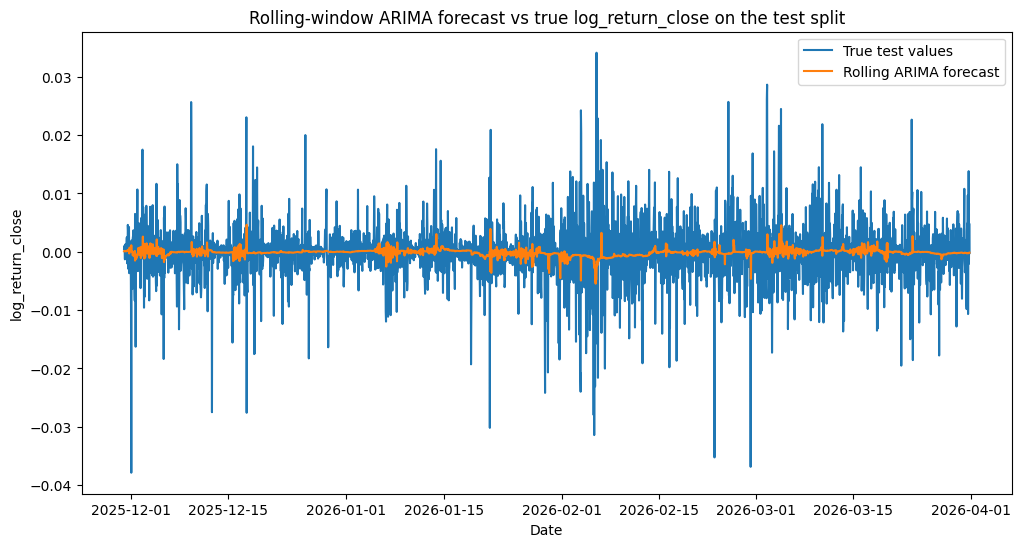

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df["y_true"], label="True test values")
plt.plot(comparison_df.index, comparison_df["y_pred"], label="Rolling ARIMA forecast")
plt.title("Rolling-window ARIMA forecast vs true log_return_close on the test split")
plt.xlabel("Date")
plt.ylabel("log_return_close")
plt.legend()
plt.show()

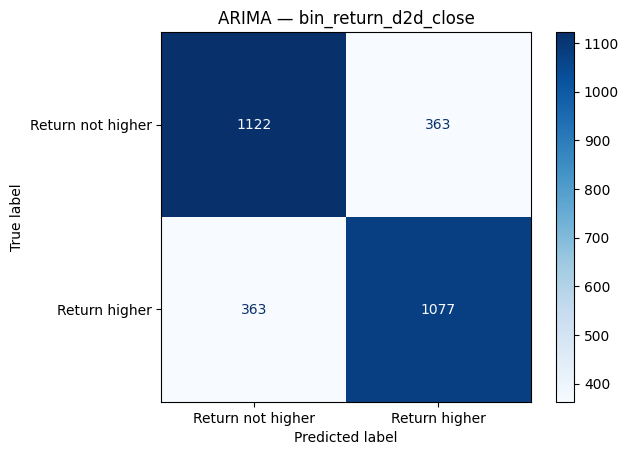

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[0, 1],
    display_labels=["Return not higher", "Return higher"], cmap="Blues")
plt.title(f"ARIMA — {CLASSIFICATION_TARGET}")
plt.show()

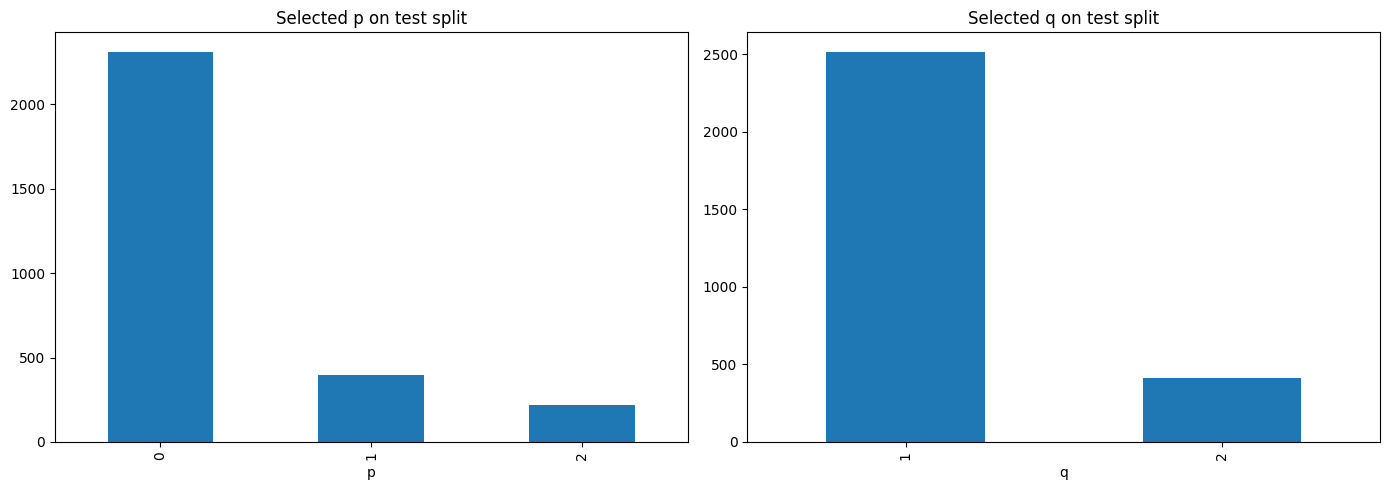

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
selected_orders_df["p"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Selected p on test split")
selected_orders_df["q"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Selected q on test split")
axes[0].set_xlabel("p")
axes[1].set_xlabel("q")
plt.tight_layout()
plt.show()

## Backtesting model

Final cash: 2450.00
Total return: 145.00%
Price direction bet accuracy: 0.5248
Strategy annualized Sharpe (risk-free=0.0%): 5.0543
Buy and hold return: -25.25%
Buy and hold annualized Sharpe: -1.5082


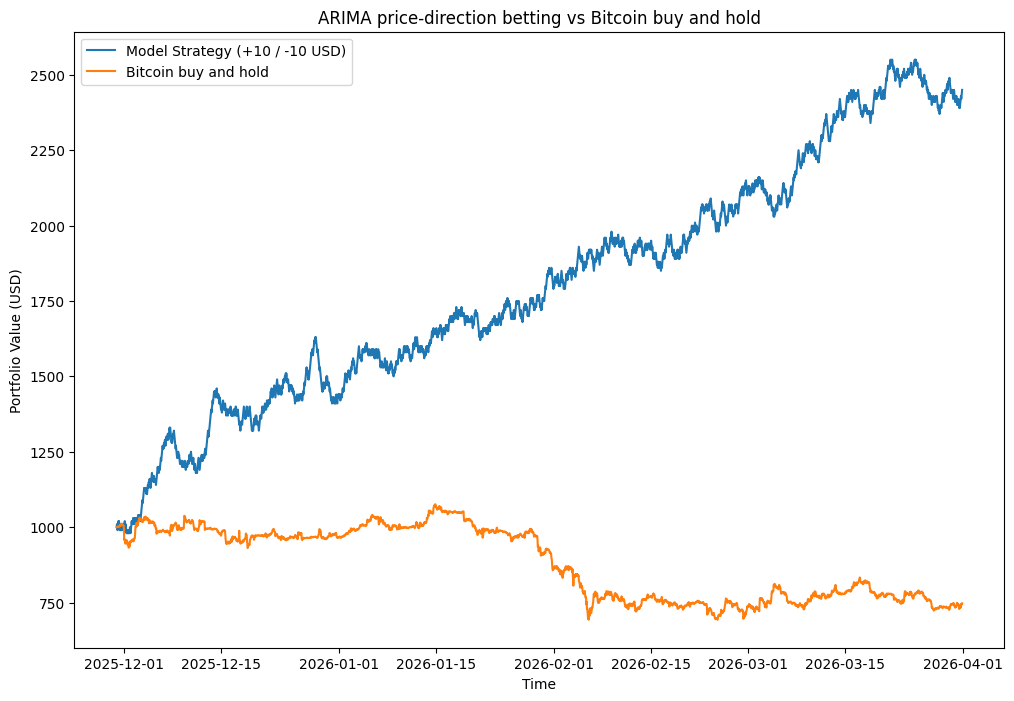

In [42]:
# Match the requested strategy: interpret predicted class 1 as UP and 0 as DOWN.
# ARIMA's classification target remains bin_return_d2d_close; price-direction
# betting accuracy below is therefore a different metric from its report.
y_return = test_returns.loc[comparison_df.index].to_numpy()
signal = np.asarray(y_pred, dtype=int).ravel()
assert len(y_return) == len(signal)
start_cash = START_CASH
cash = start_cash
movement_list = [cash]
for prediction, actual_return in zip(signal, y_return):
    if prediction == 1:
        cash += BET_PAYOUT if actual_return > 0 else -BET_PAYOUT
    else:
        cash += BET_PAYOUT if actual_return < 0 else -BET_PAYOUT
    movement_list.append(cash)
# As in the supplied example, zero price change loses for either direction.
# This fixed-stake simulation continues even if capital reaches zero.

settlement_index = comparison_df.index + pd.Timedelta(milliseconds=TIMEFRAME_DICT[TIMEFRAME])
curve_index = pd.DatetimeIndex([comparison_df.index[0]]).append(settlement_index)
strategy_curve = pd.Series(movement_list, index=curve_index, name="Model Strategy")
# Compound actual simple returns: cumsum is only an approximation to buy and hold.
buy_and_hold_curve = pd.Series(
    np.r_[start_cash, start_cash * np.cumprod(1 + y_return)],
    index=curve_index, name="Bitcoin buy and hold")

RISK_FREE_ANNUAL = 0.0
# Crypto trades 24/7: 8760 hourly periods per 365-day year.
periods_per_year = (365 * 24 * 60 * 60 * 1000) / TIMEFRAME_DICT[TIMEFRAME]

def annualized_sharpe(equity, periods_per_year, risk_free_annual=0.0):
    equity = np.asarray(equity, dtype=float)
    if (len(equity) < 3 or not np.isfinite(equity).all()
            or (equity <= 0).any()):
        return np.nan  # Percentage-return Sharpe is not reported after insolvency.
    returns = np.diff(equity) / equity[:-1]
    risk_free_per_period = np.expm1(np.log1p(risk_free_annual) / periods_per_year)
    excess_returns = returns - risk_free_per_period
    volatility = excess_returns.std(ddof=1)
    if np.isclose(volatility, 0.0):
        return np.nan
    # Conventional square-root annualization; not adjusted for autocorrelation.
    return np.sqrt(periods_per_year) * excess_returns.mean() / volatility

strategy_sharpe = annualized_sharpe(strategy_curve, periods_per_year, RISK_FREE_ANNUAL)
buy_and_hold_sharpe = annualized_sharpe(buy_and_hold_curve, periods_per_year, RISK_FREE_ANNUAL)
backtest_results = comparison_df[["true_class", "predicted_class"]].copy()
backtest_results["price_return"] = y_return
backtest_results["pnl_usd"] = np.diff(movement_list)
backtest_results["cash"] = movement_list[1:]

print(f"Final cash: {cash:.2f}")
print(f"Total return: {(cash - start_cash) / start_cash * 100:.2f}%")
print(f"Price direction bet accuracy: {(backtest_results.pnl_usd > 0).mean():.4f}")
print(f"Strategy annualized Sharpe (risk-free={RISK_FREE_ANNUAL:.1%}): {strategy_sharpe:.4f}")
print(f"Buy and hold return: {(buy_and_hold_curve.iloc[-1] / start_cash - 1) * 100:.2f}%")
print(f"Buy and hold annualized Sharpe: {buy_and_hold_sharpe:.4f}")
if (strategy_curve <= 0).any():
    print("Strategy reached non-positive capital: Sharpe is undefined (NaN).")
plt.figure(figsize=(12, 8))
plt.plot(strategy_curve.index, strategy_curve, label="Model Strategy (+10 / -10 USD)")
plt.plot(buy_and_hold_curve.index, buy_and_hold_curve, label="Bitcoin buy and hold")
plt.xlabel("Time")
plt.ylabel("Portfolio Value (USD)")
plt.title("ARIMA price-direction betting vs Bitcoin buy and hold")
plt.legend()
plt.show()

In [47]:
# ============================================================
# 1. PREPARE DATA — ARMA / ARIMA
# ============================================================

# y_pred powinno zawierać klasy wyznaczone wcześniej:
# forecast_log_return[t] > actual_log_return[t-1]
predictions_raw = np.asarray(y_pred).ravel()

# Walidacja przed konwersją do int, aby nie zaokrąglić
# przypadkowo prognoz ciągłych do klas.
if (
    len(predictions_raw) == 0
    or not np.isfinite(predictions_raw).all()
    or not np.isin(predictions_raw, [0, 1]).all()
):
    raise ValueError(
        "y_pred musi zawierać klasy 0/1, "
        "a nie ciągłe prognozy zwrotów logarytmicznych."
    )

predictions = predictions_raw.astype(int)

# Indeks świec, dla których wcześniej wykonano prognozy.
prediction_index = comparison_df.index

if len(predictions) != len(prediction_index):
    raise ValueError(
        f"Prediction length mismatch: "
        f"{len(predictions)} vs {len(prediction_index)}"
    )

if (
    not data.index.is_unique
    or not data.index.is_monotonic_increasing
):
    raise ValueError(
        "Indeks data musi być uporządkowany i bez duplikatów."
    )

if (
    not prediction_index.is_unique
    or not prediction_index.is_monotonic_increasing
):
    raise ValueError(
        "Indeks predykcji musi być uporządkowany i bez duplikatów."
    )

# Jeżeli predykcje są Series, sprawdzamy również ich indeks.
if isinstance(y_pred, pd.Series):
    if not y_pred.index.equals(prediction_index):
        raise ValueError(
            "Indeks y_pred nie odpowiada comparison_df.index."
        )

# Korzystamy z prostych zwrotów, zgodnie z Twoją strategią.
# EPSILON = 0.001 oznacza tutaj zmianę ceny o 0.1%.
returns_series = data["return_close"].astype(float)

# Dla prognozowanej świecy t:
# previous_return = rzeczywisty zwrot świecy t-1
# future_return   = rzeczywisty zwrot świecy t
#
# shift wykonujemy na CAŁYM szeregu, przed wyborem testu,
# aby zachować poprzedni zwrot dla pierwszej prognozy.
previous_returns = (
    returns_series
    .shift(1)
    .reindex(prediction_index)
    .to_numpy()
)

future_returns = (
    returns_series
    .reindex(prediction_index)
    .to_numpy()
)

if (
    not np.isfinite(previous_returns).all()
    or not np.isfinite(future_returns).all()
):
    raise ValueError(
        "Brakuje zwrotów dla prognozowanych świec "
        "lub ich poprzednich obserwacji."
    )

# Sprawdzenie, czy poprzednia obserwacja rzeczywiście
# poprzedza prognozę o dokładnie jeden interwał.
positions = data.index.get_indexer(prediction_index)

if (positions < 1).any():
    raise ValueError(
        "Brakuje prognozowanej świecy lub jej poprzednika."
    )

expected_interval = pd.Timedelta(
    milliseconds=TIMEFRAME_DICT[TIMEFRAME]
)

actual_intervals = (
    prediction_index - data.index[positions - 1]
)

if not (actual_intervals == expected_interval).all():
    raise ValueError(
        "W danych występują luki przed prognozowanymi świecami."
    )


MODEL BACKTEST RESULTS
Epsilon:                      0.001
Number of observations:       2925
Number of bets:               795
Bet frequency:                0.2718 (27.18%)
----------------------------------------------------------------------
UP bets:                      374
DOWN bets:                    421
UP accuracy:                  0.5187
DOWN accuracy:                0.5558
----------------------------------------------------------------------
Confirmed bets:               6
Confirmed accuracy:           0.3333
Neutral-zone bets:            789
Neutral-zone accuracy:        0.5399
----------------------------------------------------------------------
Winning bets:                 428
Losing bets:                  367
Overall bet accuracy:         0.5384 (53.84%)
----------------------------------------------------------------------
Starting cash:                1000.00 USDT
Final cash:                   1610.00 USDT
Net profit:                   610.00 USDT
Total return:    

,Strategy,Number of Bets,Bet Accuracy,Final Cash,Total Return (%),Sharpe Ratio,Bankrupt
0,ARIMA,795,0.5384,1610.0,61.0,4.2082,False
1,Momentum,2156,0.4768,0.0,-100.0,-1.5613,True
2,Random,795,0.5170,1270.0,27.0,1.8266,False



FIRST MODEL BETS:


,previous_return,prediction,future_return,signal_type,decision,pnl_usd,cash
1,0.000545,0,0.001008,NEUTRAL,DOWN,-10.0,990.0
3,0.000213,0,-0.001296,NEUTRAL,DOWN,10.0,1000.0
6,-0.000565,1,-0.000817,NEUTRAL,UP,-10.0,990.0
7,-0.000817,1,0.001266,NEUTRAL,UP,10.0,1000.0
9,0.000764,0,0.002378,NEUTRAL,DOWN,-10.0,990.0
17,-0.000707,1,0.004264,NEUTRAL,UP,10.0,1000.0
20,-0.000309,1,0.000010,NEUTRAL,UP,10.0,1010.0
21,0.000010,1,-0.001587,NEUTRAL,UP,-10.0,1000.0
24,0.000560,0,-0.009485,NEUTRAL,DOWN,10.0,1010.0
36,-0.000659,0,-0.005754,NEUTRAL,DOWN,10.0,1020.0


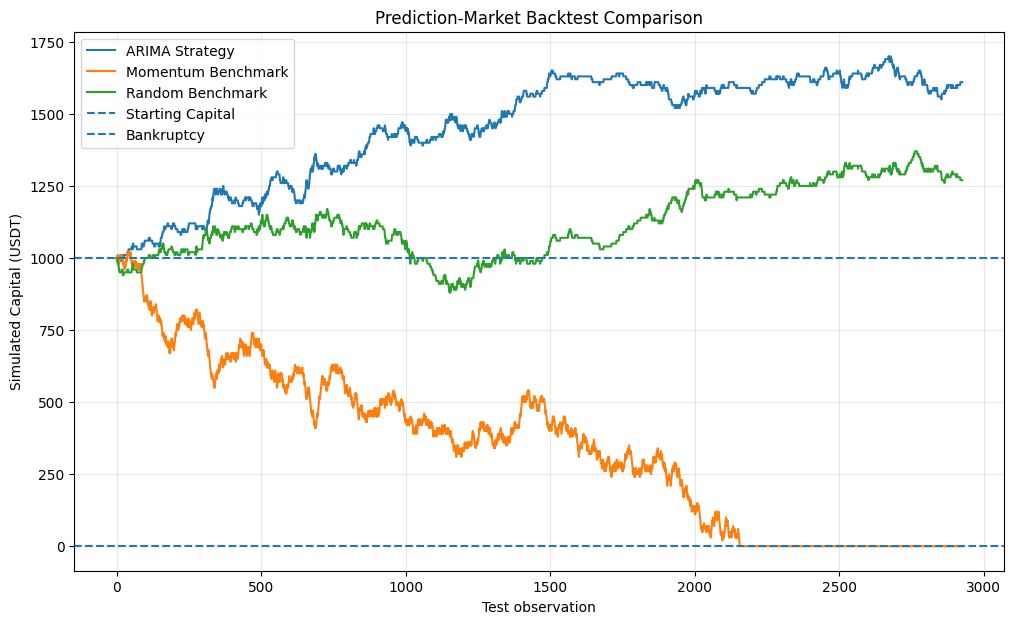

In [49]:
# ============================================================
# BACKTESTING - PREDICTION MARKET
# MODEL + MOMENTUM + RANDOM BENCHMARK
# ============================================================

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

EPSILON = 0.001

START_CASH = 1000.0
BET_PAYOUT = 10.0

RISK_FREE_ANNUAL = 0.0
RANDOM_SEED = 42


# ============================================================
# 1. PREPARE DATA — ARMA / ARIMA
# ============================================================

# y_pred powinno zawierać klasy wyznaczone wcześniej:
# forecast_log_return[t] > actual_log_return[t-1]
predictions_raw = np.asarray(y_pred).ravel()

# Walidacja przed konwersją do int, aby nie zaokrąglić
# przypadkowo prognoz ciągłych do klas.
if (
    len(predictions_raw) == 0
    or not np.isfinite(predictions_raw).all()
    or not np.isin(predictions_raw, [0, 1]).all()
):
    raise ValueError(
        "y_pred musi zawierać klasy 0/1, "
        "a nie ciągłe prognozy zwrotów logarytmicznych."
    )

predictions = predictions_raw.astype(int)

# Indeks świec, dla których wcześniej wykonano prognozy.
prediction_index = comparison_df.index

if len(predictions) != len(prediction_index):
    raise ValueError(
        f"Prediction length mismatch: "
        f"{len(predictions)} vs {len(prediction_index)}"
    )

if (
    not data.index.is_unique
    or not data.index.is_monotonic_increasing
):
    raise ValueError(
        "Indeks data musi być uporządkowany i bez duplikatów."
    )

if (
    not prediction_index.is_unique
    or not prediction_index.is_monotonic_increasing
):
    raise ValueError(
        "Indeks predykcji musi być uporządkowany i bez duplikatów."
    )

# Jeżeli predykcje są Series, sprawdzamy również ich indeks.
if isinstance(y_pred, pd.Series):
    if not y_pred.index.equals(prediction_index):
        raise ValueError(
            "Indeks y_pred nie odpowiada comparison_df.index."
        )

# Korzystamy z prostych zwrotów, zgodnie z Twoją strategią.
# EPSILON = 0.001 oznacza tutaj zmianę ceny o 0.1%.
returns_series = data["return_close"].astype(float)

# Dla prognozowanej świecy t:
# previous_return = rzeczywisty zwrot świecy t-1
# future_return   = rzeczywisty zwrot świecy t
#
# shift wykonujemy na CAŁYM szeregu, przed wyborem testu,
# aby zachować poprzedni zwrot dla pierwszej prognozy.
previous_returns = (
    returns_series
    .shift(1)
    .reindex(prediction_index)
    .to_numpy()
)

future_returns = (
    returns_series
    .reindex(prediction_index)
    .to_numpy()
)

if (
    not np.isfinite(previous_returns).all()
    or not np.isfinite(future_returns).all()
):
    raise ValueError(
        "Brakuje zwrotów dla prognozowanych świec "
        "lub ich poprzednich obserwacji."
    )

# Sprawdzenie, czy poprzednia obserwacja rzeczywiście
# poprzedza prognozę o dokładnie jeden interwał.
positions = data.index.get_indexer(prediction_index)

if (positions < 1).any():
    raise ValueError(
        "Brakuje prognozowanej świecy lub jej poprzednika."
    )

expected_interval = pd.Timedelta(
    milliseconds=TIMEFRAME_DICT[TIMEFRAME]
)

actual_intervals = (
    prediction_index - data.index[positions - 1]
)

if not (actual_intervals == expected_interval).all():
    raise ValueError(
        "W danych występują luki przed prognozowanymi świecami."
    )

# ============================================================
# 2. MODEL STRATEGY
# ============================================================
#
# RULES:
#
# r[t] > EPSILON and prediction == 1
#       -> BET UP
#
# r[t] < -EPSILON and prediction == 0
#       -> BET DOWN
#
# |r[t]| <= EPSILON and prediction == 1
#       -> BET UP
#
# |r[t]| <= EPSILON and prediction == 0
#       -> BET DOWN
#
# Otherwise:
#       -> NO BET
#
# Settlement:
#
# UP wins   if r[t+1] > 0
# DOWN wins if r[t+1] < 0
#
# Bankruptcy:
#
# cash <= 0 -> stop betting permanently
# ============================================================

cash = START_CASH

cash_history = [cash]
pnl_history = []
decision_history = []
signal_type_history = []

bets = 0
wins = 0
losses = 0

up_bets = 0
down_bets = 0

up_wins = 0
down_wins = 0

confirmed_bets = 0
confirmed_wins = 0

neutral_bets = 0
neutral_wins = 0

bankrupt = False


for prediction, previous_return, future_return in zip(
    predictions,
    previous_returns,
    future_returns
):

    # --------------------------------------------------------
    # BANKRUPTCY
    # --------------------------------------------------------

    if bankrupt or cash <= 0:

        bankrupt = True

        pnl_history.append(0.0)
        decision_history.append("BANKRUPT")
        signal_type_history.append("BANKRUPT")

        cash_history.append(0.0)

        continue


    pnl = 0.0
    decision = "NO BET"
    signal_type = "NO BET"


    # --------------------------------------------------------
    # CLEARLY POSITIVE PREVIOUS RETURN + prediction = 1
    # -> UP
    # --------------------------------------------------------

    if previous_return > EPSILON and prediction == 1:

        decision = "UP"
        signal_type = "CONFIRMED"

        bets += 1
        confirmed_bets += 1
        up_bets += 1

        if future_return > 0:

            pnl = BET_PAYOUT

            wins += 1
            confirmed_wins += 1
            up_wins += 1

        else:

            pnl = -BET_PAYOUT
            losses += 1


    # --------------------------------------------------------
    # CLEARLY NEGATIVE PREVIOUS RETURN + prediction = 0
    # -> DOWN
    # --------------------------------------------------------

    elif previous_return < -EPSILON and prediction == 0:

        decision = "DOWN"
        signal_type = "CONFIRMED"

        bets += 1
        confirmed_bets += 1
        down_bets += 1

        if future_return < 0:

            pnl = BET_PAYOUT

            wins += 1
            confirmed_wins += 1
            down_wins += 1

        else:

            pnl = -BET_PAYOUT
            losses += 1


    # --------------------------------------------------------
    # NEUTRAL ZONE
    #
    # |r[t]| <= EPSILON
    #
    # prediction = 1 -> UP
    # prediction = 0 -> DOWN
    # --------------------------------------------------------

    elif abs(previous_return) <= EPSILON:

        signal_type = "NEUTRAL"

        bets += 1
        neutral_bets += 1


        # Prediction = 1 -> UP
        if prediction == 1:

            decision = "UP"
            up_bets += 1

            if future_return > 0:

                pnl = BET_PAYOUT

                wins += 1
                neutral_wins += 1
                up_wins += 1

            else:

                pnl = -BET_PAYOUT
                losses += 1


        # Prediction = 0 -> DOWN
        else:

            decision = "DOWN"
            down_bets += 1

            if future_return < 0:

                pnl = BET_PAYOUT

                wins += 1
                neutral_wins += 1
                down_wins += 1

            else:

                pnl = -BET_PAYOUT
                losses += 1


    # --------------------------------------------------------
    # NO BET
    # --------------------------------------------------------

    else:

        pnl = 0.0


    # --------------------------------------------------------
    # BANKRUPTCY PROTECTION
    # --------------------------------------------------------
    #
    # Strategy cannot lose more money than currently available.
    #

    if pnl < 0:

        pnl = -min(
            abs(pnl),
            cash
        )


    cash += pnl

    cash = max(
        cash,
        0.0
    )


    if cash <= 0:
        bankrupt = True


    pnl_history.append(pnl)
    decision_history.append(decision)
    signal_type_history.append(signal_type)

    cash_history.append(cash)


# ============================================================
# 3. MODEL STATISTICS
# ============================================================

number_of_observations = len(predictions)

bet_frequency = (
    bets / number_of_observations
    if number_of_observations > 0
    else np.nan
)

bet_accuracy = (
    wins / bets
    if bets > 0
    else np.nan
)

up_accuracy = (
    up_wins / up_bets
    if up_bets > 0
    else np.nan
)

down_accuracy = (
    down_wins / down_bets
    if down_bets > 0
    else np.nan
)

confirmed_accuracy = (
    confirmed_wins / confirmed_bets
    if confirmed_bets > 0
    else np.nan
)

neutral_accuracy = (
    neutral_wins / neutral_bets
    if neutral_bets > 0
    else np.nan
)

net_profit = (
    cash - START_CASH
)

total_return = (
    net_profit / START_CASH
) * 100


# ============================================================
# 4. SHARPE RATIO FUNCTION
# ============================================================

periods_per_year = (
    (365 * 24 * 60 * 60 * 1000)
    / TIMEFRAME_DICT[TIMEFRAME]
)


def annualized_sharpe(
    equity,
    periods_per_year,
    risk_free_annual=0.0
):

    equity = np.asarray(
        equity,
        dtype=float
    )

    if len(equity) < 3:
        return np.nan

    if not np.isfinite(equity).all():
        return np.nan

    # Calculate returns only while capital is positive
    valid_returns = []

    for previous_cash, current_cash in zip(
        equity[:-1],
        equity[1:]
    ):

        if previous_cash <= 0:
            break

        valid_returns.append(
            (current_cash - previous_cash)
            / previous_cash
        )


    returns_array = np.asarray(
        valid_returns,
        dtype=float
    )


    if len(returns_array) < 2:
        return np.nan


    risk_free_per_period = np.expm1(
        np.log1p(risk_free_annual)
        / periods_per_year
    )


    excess_returns = (
        returns_array
        - risk_free_per_period
    )


    volatility = excess_returns.std(
        ddof=1
    )


    if np.isclose(
        volatility,
        0.0
    ):
        return np.nan


    return (
        np.sqrt(periods_per_year)
        * excess_returns.mean()
        / volatility
    )


strategy_sharpe = annualized_sharpe(
    cash_history,
    periods_per_year,
    RISK_FREE_ANNUAL
)


# ============================================================
# 5. MOMENTUM BENCHMARK
# ============================================================
#
# No model is used.
#
# r[t] > 0 -> UP
# r[t] < 0 -> DOWN
#
# Bankruptcy at 0 USDT.
# ============================================================

momentum_cash = START_CASH

momentum_cash_history = [
    momentum_cash
]

momentum_bets = 0
momentum_wins = 0
momentum_losses = 0

momentum_bankrupt = False


for previous_return, future_return in zip(
    previous_returns,
    future_returns
):

    # --------------------------------------------------------
    # BANKRUPTCY
    # --------------------------------------------------------

    if momentum_bankrupt or momentum_cash <= 0:

        momentum_bankrupt = True

        momentum_cash_history.append(
            0.0
        )

        continue


    pnl = 0.0


    # --------------------------------------------------------
    # MOMENTUM UP
    # --------------------------------------------------------

    if previous_return > 0:

        momentum_bets += 1

        if future_return > 0:

            pnl = BET_PAYOUT
            momentum_wins += 1

        else:

            pnl = -BET_PAYOUT
            momentum_losses += 1


    # --------------------------------------------------------
    # MOMENTUM DOWN
    # --------------------------------------------------------

    elif previous_return < 0:

        momentum_bets += 1

        if future_return < 0:

            pnl = BET_PAYOUT
            momentum_wins += 1

        else:

            pnl = -BET_PAYOUT
            momentum_losses += 1


    # --------------------------------------------------------
    # EXACTLY ZERO -> NO BET
    # --------------------------------------------------------

    else:

        pnl = 0.0


    # --------------------------------------------------------
    # BANKRUPTCY PROTECTION
    # --------------------------------------------------------

    if pnl < 0:

        pnl = -min(
            abs(pnl),
            momentum_cash
        )


    momentum_cash += pnl

    momentum_cash = max(
        momentum_cash,
        0.0
    )


    if momentum_cash <= 0:
        momentum_bankrupt = True


    momentum_cash_history.append(
        momentum_cash
    )


momentum_accuracy = (
    momentum_wins / momentum_bets
    if momentum_bets > 0
    else np.nan
)

momentum_return = (
    (momentum_cash - START_CASH)
    / START_CASH
) * 100


momentum_sharpe = annualized_sharpe(
    momentum_cash_history,
    periods_per_year,
    RISK_FREE_ANNUAL
)


# ============================================================
# 6. RANDOM BENCHMARK
# ============================================================
#
# Random strategy bets only when the MODEL strategy
# would place a bet.
#
# Random direction:
#
# 1 -> UP
# 0 -> DOWN
#
# Fixed seed ensures reproducibility.
#
# Bankruptcy at 0 USDT.
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

random_cash = START_CASH

random_cash_history = [
    random_cash
]

random_bets = 0
random_wins = 0
random_losses = 0

random_bankrupt = False


for model_decision, future_return in zip(
    decision_history,
    future_returns
):

    # --------------------------------------------------------
    # BANKRUPTCY
    # --------------------------------------------------------

    if random_bankrupt or random_cash <= 0:

        random_bankrupt = True

        random_cash_history.append(
            0.0
        )

        continue


    pnl = 0.0


    # --------------------------------------------------------
    # RANDOM BET
    # --------------------------------------------------------

    if model_decision in ["UP", "DOWN"]:

        random_bets += 1

        random_prediction = rng.integers(
            0,
            2
        )


        # Random UP
        if random_prediction == 1:

            if future_return > 0:

                pnl = BET_PAYOUT
                random_wins += 1

            else:

                pnl = -BET_PAYOUT
                random_losses += 1


        # Random DOWN
        else:

            if future_return < 0:

                pnl = BET_PAYOUT
                random_wins += 1

            else:

                pnl = -BET_PAYOUT
                random_losses += 1


    # --------------------------------------------------------
    # NO BET
    # --------------------------------------------------------

    else:

        pnl = 0.0


    # --------------------------------------------------------
    # BANKRUPTCY PROTECTION
    # --------------------------------------------------------

    if pnl < 0:

        pnl = -min(
            abs(pnl),
            random_cash
        )


    random_cash += pnl

    random_cash = max(
        random_cash,
        0.0
    )


    if random_cash <= 0:
        random_bankrupt = True


    random_cash_history.append(
        random_cash
    )


random_accuracy = (
    random_wins / random_bets
    if random_bets > 0
    else np.nan
)

random_return = (
    (random_cash - START_CASH)
    / START_CASH
) * 100


random_sharpe = annualized_sharpe(
    random_cash_history,
    periods_per_year,
    RISK_FREE_ANNUAL
)


# ============================================================
# 7. DETAILED MODEL RESULTS
# ============================================================

print()
print("=" * 70)
print("MODEL BACKTEST RESULTS")
print("=" * 70)

print(
    f"Epsilon:                      "
    f"{EPSILON}"
)

print(
    f"Number of observations:       "
    f"{number_of_observations}"
)

print(
    f"Number of bets:               "
    f"{bets}"
)

print(
    f"Bet frequency:                "
    f"{bet_frequency:.4f} "
    f"({bet_frequency * 100:.2f}%)"
)

print("-" * 70)

print(
    f"UP bets:                      "
    f"{up_bets}"
)

print(
    f"DOWN bets:                    "
    f"{down_bets}"
)

print(
    f"UP accuracy:                  "
    f"{up_accuracy:.4f}"
)

print(
    f"DOWN accuracy:                "
    f"{down_accuracy:.4f}"
)

print("-" * 70)

print(
    f"Confirmed bets:               "
    f"{confirmed_bets}"
)

print(
    f"Confirmed accuracy:           "
    f"{confirmed_accuracy:.4f}"
)

print(
    f"Neutral-zone bets:            "
    f"{neutral_bets}"
)

print(
    f"Neutral-zone accuracy:        "
    f"{neutral_accuracy:.4f}"
)

print("-" * 70)

print(
    f"Winning bets:                 "
    f"{wins}"
)

print(
    f"Losing bets:                  "
    f"{losses}"
)

print(
    f"Overall bet accuracy:         "
    f"{bet_accuracy:.4f} "
    f"({bet_accuracy * 100:.2f}%)"
)

print("-" * 70)

print(
    f"Starting cash:                "
    f"{START_CASH:.2f} USDT"
)

print(
    f"Final cash:                   "
    f"{cash:.2f} USDT"
)

print(
    f"Net profit:                   "
    f"{net_profit:.2f} USDT"
)

print(
    f"Total return:                 "
    f"{total_return:.2f}%"
)

print(
    f"Sharpe ratio:                 "
    f"{strategy_sharpe:.4f}"
)

print(
    f"Bankrupt:                     "
    f"{bankrupt}"
)

print("=" * 70)


# ============================================================
# 8. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Strategy": [
        "ARIMA",
        "Momentum",
        "Random"
    ],

    "Number of Bets": [
        bets,
        momentum_bets,
        random_bets
    ],

    "Bet Accuracy": [
        bet_accuracy,
        momentum_accuracy,
        random_accuracy
    ],

    "Final Cash": [
        cash,
        momentum_cash,
        random_cash
    ],

    "Total Return (%)": [
        total_return,
        momentum_return,
        random_return
    ],

    "Sharpe Ratio": [
        strategy_sharpe,
        momentum_sharpe,
        random_sharpe
    ],

    "Bankrupt": [
        bankrupt,
        momentum_bankrupt,
        random_bankrupt
    ]

})


comparison_display = comparison.copy()

comparison_display["Bet Accuracy"] = (
    comparison_display["Bet Accuracy"]
    .round(4)
)

comparison_display["Final Cash"] = (
    comparison_display["Final Cash"]
    .round(2)
)

comparison_display["Total Return (%)"] = (
    comparison_display["Total Return (%)"]
    .round(2)
)

comparison_display["Sharpe Ratio"] = (
    comparison_display["Sharpe Ratio"]
    .round(4)
)


print()
print("=" * 80)
print("BACKTEST COMPARISON")
print("=" * 80)

display(
    comparison_display
)


# ============================================================
# 9. DETAILED RESULTS DATAFRAME
# ============================================================

backtest_results = pd.DataFrame({

    "previous_return": previous_returns,

    "prediction": predictions,

    "future_return": future_returns,

    "signal_type": signal_type_history,

    "decision": decision_history,

    "pnl_usd": pnl_history,

    "cash": cash_history[1:]

})


print()
print("FIRST MODEL BETS:")

display(
    backtest_results[
        backtest_results["decision"].isin(
            ["UP", "DOWN"]
        )
    ].head(20)
)


# ============================================================
# 10. EQUITY CURVES
# ============================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    cash_history,
    label="ARIMA Strategy"
)

plt.plot(
    momentum_cash_history,
    label="Momentum Benchmark"
)

plt.plot(
    random_cash_history,
    label="Random Benchmark"
)

plt.axhline(
    y=START_CASH,
    linestyle="--",
    label="Starting Capital"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Bankruptcy"
)

plt.xlabel(
    "Test observation"
)

plt.ylabel(
    "Simulated Capital (USDT)"
)

plt.title(
    "Prediction-Market Backtest Comparison"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()